# **Project Name - Flipkart Customer Service Satisfaction**

# **Project Summary**

This project focuses on analyzing customer interactions, feedback, and satisfaction scores from Flipkart to identify key factors influencing customer experience and service quality. By leveraging Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn, the project aims to uncover trends in customer sentiment, improve support strategies, and enhance overall satisfaction.

# **Github Link**

https://github.com/krishpatel-dev/Flipkart_Customer_Service_Satisfaction.git

# **Importing the Required** **Libraries**

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd # importing pandas for  handling and data manuplation
import numpy as np  #importing numpy for mathematical operation
import matplotlib.pyplot as plt #for data visualisation
import seaborn as sns   #for data visualisation

In [4]:
from sklearn.model_selection import train_test_split #  splitting the dataset into traning and test sets
from sklearn.ensemble import RandomForestClassifier  #machine learning model for classification
from sklearn.metrics import accuracy_score , classification_report    #TO eevaluate model performance

# **Loading the Dataset**

In [5]:
#Loading datasheet
file_path = "Customer_support_data.csv"
df = pd.read_csv(file_path)

# **For Data cleaning and Preprocessing**

In [6]:
#Converting date and columns to datetime format
date_cols = ["order_date_time" , "Issue_reported at", "issue_responded", "Survey_response_Date"]
for col in date_cols:
  df[col] = pd.to_datetime(df[col], format="%d/%m/%Y %H:%M", errors = "coerce")         #error = coerce ensures invalid date values are converted to NaT i.e. not a time

# **Handling missing values**

In [7]:
#df['Customer Remarks'].fillna("No Remarks", inplace=True)
#df['Item_price'].fillna(df['Item_price'].median(), inplace=True)
#df.drop(columns=['Customer_City', 'connected_handling_time'], inplace=True)  # Too many missing values

df['Customer Remarks'] = df['Customer Remarks'].fillna("No Remarks")     #Filling missing values in customer remarks with no remarks
df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())    # fills missing values


# **Dropping columns that have too many missing values**

In [8]:
if 'Customer_City' in df.columns:
    df.drop(columns=['Customer_City'], inplace=True)  # Too many missing values
if 'connected_handling_time' in df.columns:
    df.drop(columns=['connected_handling_time'], inplace=True)

In [9]:
#Feature enginnering
#Calculating Response time

df["response_time"] = (df["issue_responded"] - df["Issue_reported at"]).dt.total_seconds()
df["response_time"] = df["response_time"].fillna(df["response_time"].median())

## **Analyzing and Visulaizing data**

<function matplotlib.pyplot.show(close=None, block=None)>

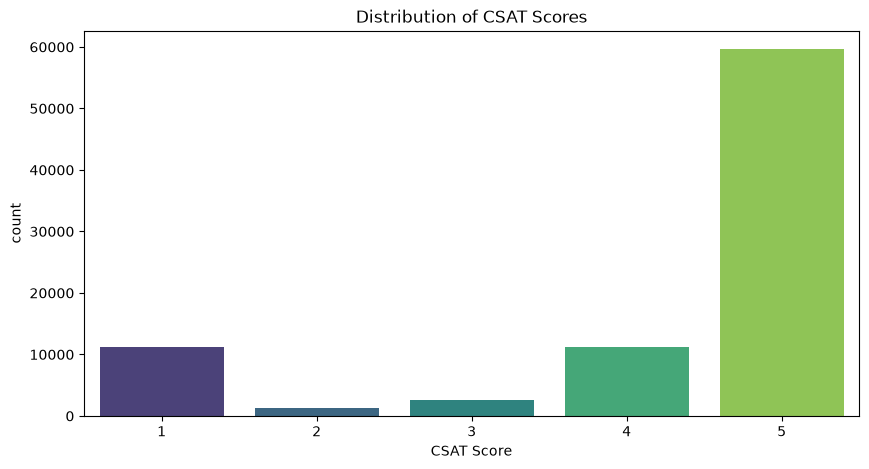

In [10]:
#For CSAT Score distribution
plt.figure(figsize=(10,5))
sns.countplot(x="CSAT Score", data = df , hue="CSAT Score", palette = "viridis", legend=False)
plt.title("Distribution of CSAT Scores")
plt.show

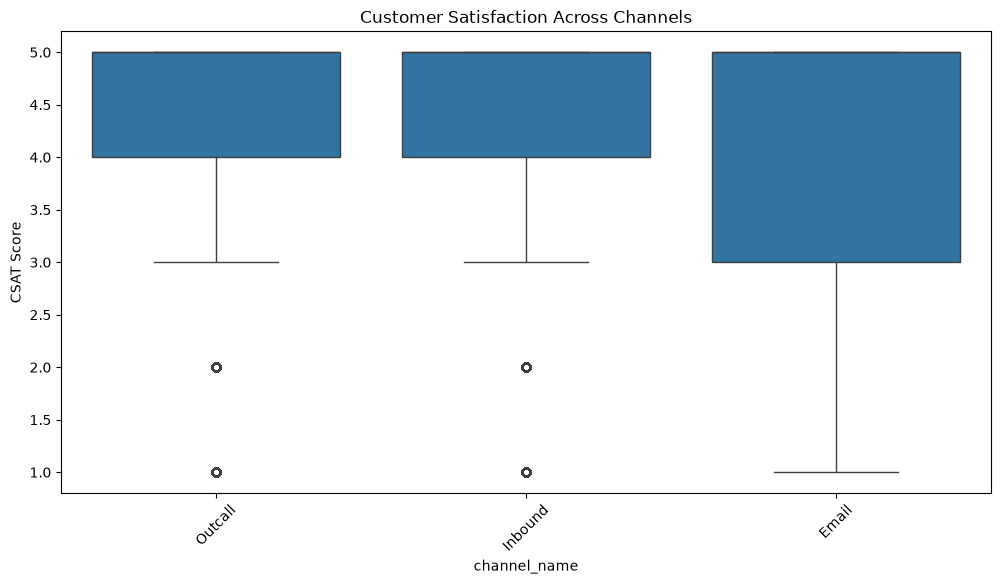

In [11]:
#Satisfaction across different support channels/ differnet mediums;
plt.figure(figsize = (12,6))
sns.boxplot(x = "channel_name", y = "CSAT Score" , data = df)
plt.xticks(rotation = 45)
plt.title("Customer Satisfaction Across Channels")
plt.show()

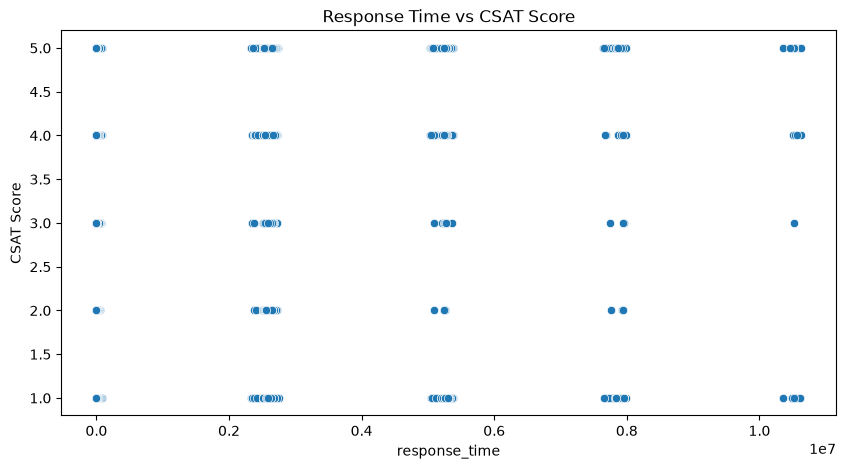

In [12]:
# Comparing Response Time vs Csat Score
plt.figure(figsize = (10 , 5))
sns.scatterplot(x = "response_time" , y = "CSAT Score" , data = df)
plt.title("Response Time vs CSAT Score")
plt.show()

# **#Model traning**

In [13]:
#Selcting relevant features for predictions
features = ["response_time" , "Item_price", "channel_name", "category" , "Tenure Bucket" , "Agent Shift"]
df_model = df[features + ["CSAT Score"]]
df_model = pd.get_dummies(df_model , drop_first = True) #One hot encoding for categorial features

In [14]:
#Spitting Data Into Train and Test Sets
X = df_model.drop(columns=['CSAT Score'])
y = df_model['CSAT Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **Training the Machine Learning Model**

In [15]:
model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
model.fit(X_train , y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#**Predicitons**

In [16]:
y_pred = model.predict(X_test)

## **Model Performance Evaluation**

In [17]:
print("Model Accuracy:" , accuracy_score(y_test , y_pred))
print(classification_report(y_test , y_pred))

Model Accuracy: 0.6538819695029682
              precision    recall  f1-score   support

           1       0.23      0.09      0.13      2241
           2       0.01      0.00      0.01       227
           3       0.04      0.01      0.02       503
           4       0.13      0.03      0.05      2277
           5       0.70      0.92      0.80     11934

    accuracy                           0.65     17182
   macro avg       0.23      0.21      0.20     17182
weighted avg       0.54      0.65      0.58     17182

